In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
import re
from bs4 import BeautifulSoup
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
training_data = pd.read_csv('/content/samsum-train.csv')
test_data = pd.read_csv('/content/samsum-test.csv')

In [3]:
training_data.drop_duplicates(subset=['dialogue'],inplace=True)#dropping duplicates
training_data.dropna(axis=0,inplace=True)#dropping na

In [4]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14264 entries, 0 to 14731
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14264 non-null  object
 1   dialogue  14264 non-null  object
 2   summary   14264 non-null  object
dtypes: object(3)
memory usage: 445.8+ KB


In [5]:
contraction_mapping = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

In [6]:
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
def text_cleaner(text,num):
    newString = text.lower()
    newString = BeautifulSoup(newString, "lxml").text
    newString = re.sub(r'\([^)]*\)', '', newString)
    newString = re.sub('"','', newString)
    newString = ' '.join([contraction_mapping[t] if t in contraction_mapping else t for t in newString.split(" ")])
    newString = re.sub(r"'s\b","",newString)
    newString = re.sub("[^a-zA-Z]", " ", newString)
    newString = re.sub('[m]{2,}', 'mm', newString)
    if(num==0):
        tokens = [w for w in newString.split() if not w in stop_words]
    else:
        tokens=newString.split()
    long_words=[]
    for i in tokens:
        if len(i)>1:                                                 #removing short word
            long_words.append(i)
    return (" ".join(long_words)).strip()

In [8]:
#call the function
cleaned_text = []
for t in training_data['dialogue']:
    cleaned_text.append(text_cleaner(t,0))
cleaned_text[:5]

['amanda baked cookies want jerry sure amanda bring tomorrow',
 'olivia voting election oliver liberals always olivia oliver great',
 'tim hi kim bad mood tbh going lots stuff ended procrastinating tim plan kim oh know uni stuff unfucking room kim maybe tomorrow move ass everything kim going defrost fridge instead shopping eat defrosted veggies tim stuff recommend pomodoro technique use breaks chores tim really helps kim thanks maybe tim also like using post kaban style',
 'edward rachel think ove bella rachel dont say anything else edward mean rachel open fu ing door outside',
 'sam hey overheard rick say something sam know naomi say sam talking phone someone sam know sam telling happy naomi damn sam saying like roommate naomi wow feel sam thought good rommate sam nice place naomi true man naomi used love living moved boyfriend naomi know saying sam naomi honestly bothering much talk naomi see going sam want get kind confrontation though sam maybe let go sam see goes future naomi choi

In [9]:
#call the function
cleaned_summary = []
for t in training_data['summary']:
    cleaned_summary.append(text_cleaner(t,1))
cleaned_summary[:10]

['amanda baked cookies and will bring jerry some tomorrow',
 'olivia and olivier are voting for liberals in this election',
 'kim may try the pomodoro technique recommended by tim to get more stuff done',
 'edward thinks he is in love with bella rachel wants edward to open his door rachel is outside',
 'sam is confused because he overheard rick complaining about him as roommate naomi thinks sam should talk to rick sam is not sure what to do',
 'wyatt reminds neville his wedding anniversary is on the th of september neville wife is upset and it might be because neville forgot about their anniversary',
 'john did not show up for class due to some work issues with his boss cassandra his teacher told him which exercises to do and which chapter to study they are going to meet up for beer sometime this week after class',
 'sarah sends james an instrumental song he might like james knows the song the brain connects the songs to the context they were played in and brings to mind the associated

In [10]:
training_data['cleaned_text']=cleaned_text
training_data['cleaned_summary']=cleaned_summary

In [11]:
training_data.replace('', np.nan, inplace=True)
training_data.dropna(axis=0,inplace=True)

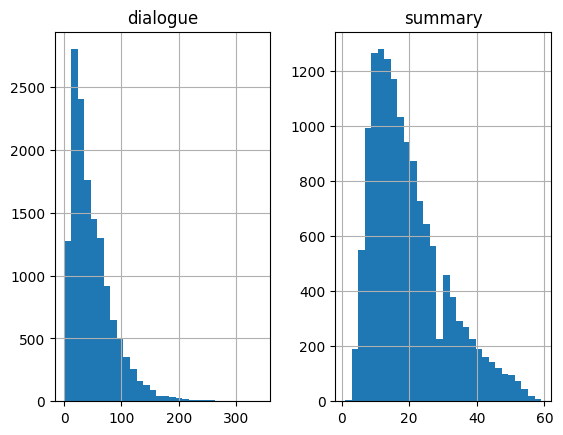

In [12]:
import matplotlib.pyplot as plt

text_word_count = []
summary_word_count = []

# populate the lists with sentence lengths
for i in training_data['cleaned_text']:
      text_word_count.append(len(i.split()))

for i in training_data['cleaned_summary']:
      summary_word_count.append(len(i.split()))

length_df = pd.DataFrame({'dialogue':text_word_count, 'summary':summary_word_count})

length_df.hist(bins = 30)
plt.show()

In [13]:
cnt=0
for i in training_data['cleaned_summary']:
    if(len(i.split())<=10):
        cnt=cnt+1
print(cnt/len(training_data['cleaned_summary']))

0.20996915311273134


In [14]:
cnt=0
for i in training_data['cleaned_text']:
    if(len(i.split())<=80):
        cnt=cnt+1
print(cnt/len(training_data['cleaned_text']))

0.8350392596747056


In [15]:
max_dialogue_len=80
max_summary_len=10

In [16]:
cleaned_text =np.array(training_data['cleaned_text'])
cleaned_summary=np.array(training_data['cleaned_summary'])

short_text=[]
short_summary=[]

for i in range(len(cleaned_text)):
    if(len(cleaned_summary[i].split())<=max_summary_len and len(cleaned_text[i].split())<=max_dialogue_len):
        short_text.append(cleaned_text[i])
        short_summary.append(cleaned_summary[i])

df=pd.DataFrame({'text':short_text,'summary':short_summary})

In [17]:
df['summary'] = df['summary'].apply(lambda x : 'sostok '+ x + ' eostok')

In [18]:
dialogues = training_data['dialogue'].values[:10000]
summaries = training_data['summary'].values[:10000]

tokenizer_dialogue = Tokenizer()
tokenizer_summary = Tokenizer()

tokenizer_dialogue.fit_on_texts(dialogues)
tokenizer_summary.fit_on_texts(summaries)

dialogue_sequences = tokenizer_dialogue.texts_to_sequences(dialogues)
summary_sequences = tokenizer_summary.texts_to_sequences(summaries)

max_dialogue_len = max(len(seq) for seq in dialogue_sequences)
max_summary_len = max(len(seq) for seq in summary_sequences)

dialogue_sequences_padded = pad_sequences(dialogue_sequences, maxlen = max_dialogue_len, padding='post')
summary_sequences_padded = pad_sequences(summary_sequences, maxlen = max_summary_len, padding='post')

vocab_size_dialogue = len(tokenizer_dialogue.word_index) + 1
vocab_size_summary = len(tokenizer_summary.word_index) + 1
embedding_dim=100
latent_dim=256

In [20]:
encoder_inputs=Input(shape=(max_dialogue_len,))
encoder_embedding=Embedding(input_dim=vocab_size_dialogue, output_dim=embedding_dim)(encoder_inputs)
encoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
encoder_outputs, state_c, state_h=encoder_lstm(encoder_embedding)
encoder_states=[state_h, state_c]

decoder_inputs=Input(shape=(None,))
decoder_embedding=Embedding(input_dim=vocab_size_summary, output_dim=embedding_dim)(decoder_inputs)
decoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
decoder_outputs, state_h_d, state_c_d=decoder_lstm(decoder_embedding, initial_state=encoder_states)

attention_layer=Attention()([decoder_outputs, encoder_outputs])
decoder_concat_input=Concatenate(axis=-1)([decoder_outputs, attention_layer])

decoder_dense=Dense(vocab_size_summary, activation='softmax')
decoder_outputs_final=decoder_dense(decoder_concat_input)

model=Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

decoder_input_data = summary_sequences_padded[:, :-1]
decoder_target_data = summary_sequences_padded[:, 1:]

history=model.fit([dialogue_sequences_padded, np.roll(summary_sequences_padded, -1, axis=1)], summary_sequences_padded, batch_size=64, epochs=20, validation_split=0.2) #callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.6552 - loss: 4.0359 - val_accuracy: 0.6904 - val_loss: 2.2632
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.6967 - loss: 2.1767 - val_accuracy: 0.6962 - val_loss: 2.1917
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.7005 - loss: 2.0652 - val_accuracy: 0.7188 - val_loss: 1.9109
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 210ms/step - accuracy: 0.7359 - loss: 1.7594 - val_accuracy: 0.7585 - val_loss: 1.6651
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 209ms/step - accuracy: 0.7741 - loss: 1.5062 - val_accuracy: 0.7921 - val_loss: 1.4691
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 210ms/step - accuracy: 0.8034 - loss: 1.3075 - val_accuracy: 0.8160 - val_loss: 1.3285
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - accuracy: 0.8226 - loss: 1.1598 - val_accuracy: 0.8322 - val_loss: 1.2028
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.8441 - loss: 0

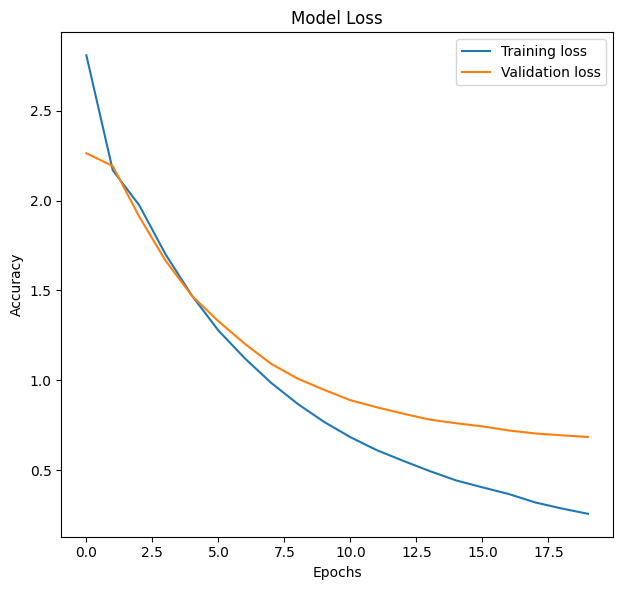

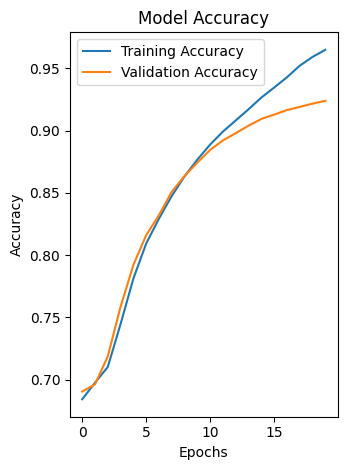

In [21]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
encoder_model=Model(encoder_inputs, [encoder_outputs, state_h, state_c])
decoder_state_input_h=Input(shape=(latent_dim,))
decoder_state_input_c=Input(shape=(latent_dim,))
decoder_hidden_state_input=Input(shape=(max_dialogue_len, latent_dim))

decoder_outputs_inference, state_h_inference, state_c_inference=decoder_lstm(decoder_embedding, initial_state=[decoder_state_input_h, decoder_state_input_c])
attention_output_inference=Attention()([decoder_outputs_inference, decoder_hidden_state_input])
decoder_concat_input_inference = Concatenate(axis=-1)([decoder_outputs_inference, attention_output_inference])
decoder_outputs_final_inference=decoder_dense(decoder_concat_input_inference)


decoder_model=Model([decoder_inputs, decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c], [decoder_outputs_final_inference, state_h_inference, state_c_inference])

In [26]:
def generate_summary(input_text):
    # Tokenize & pad input text
    input_seq = tokenizer_dialogue.texts_to_sequences([input_text])
    input_seq_padded = pad_sequences(input_seq, maxlen=max_dialogue_len, padding='post')

    # Encode input
    encoder_out, state_h, state_c = encoder_model.predict(input_seq_padded)
    states_value = [state_h, state_c]

    # Start token (adjust if not using 'startseq')
    target_seq = np.zeros((1, 1))
    start_token = tokenizer_summary.word_index.get('sostok', 1)  # Default to 1 if 'startseq' not found
    target_seq[0, 0] = start_token

    decoded_sentence = ''

    for _ in range(max_summary_len):
        output_tokens, h, c = decoder_model.predict([target_seq, encoder_out, states_value[0], states_value[1]])

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = tokenizer_summary.index_word.get(sampled_token_index, '')

        if sampled_word == 'eostok' or sampled_word == '':
            break

        decoded_sentence += ' ' + sampled_word

        # Update target sequence with last predicted word
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        states_value = [h, c]

    return decoded_sentence.strip()

In [27]:
test_dialogue = test_data['dialogue'].iloc[0]
actual_summary = test_data['summary'].iloc[0]

# Print original and actual
print("Original Dialogue:\n", test_dialogue)
print("\nActual Summary:\n", actual_summary)

# Generate predicted summary
generated_summary = generate_summary(test_dialogue)
print("\nGenerated Summary:\n", generated_summary)

Original Dialogue:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Actual Summary:
 Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━